In [1]:
import json
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
from statistics import mean
from collections import Counter

In [2]:
import json
from collections import Counter
from statistics import mean

# Load training, development, and test data
with open('data/train-claims.json', 'r') as input_file:
    train_claim_data = json.load(input_file)

with open('data/dev-claims.json', 'r') as input_file:
    dev_claim_data = json.load(input_file)

with open('data/test-claims-unlabelled.json', 'r') as input_file:
    test_claim_data = json.load(input_file)

with open('data/evidence.json', 'r') as input_file:
    evi_data = json.load(input_file)

# EDA
claim_length = []
evidence_count = []
evidence_length = []
labels = []

for key, value in train_claim_data.items():
    claim_length.append(len(value["claim_text"]))
    evidence_count.append(len(value["evidences"]))
    evidence_length += [len(evi_data[x]) for x in value["evidences"]]
    labels.append(value["claim_label"])

print("Number of claims in the training set:", len(train_claim_data))
print("Max claim length in the training set:", max(claim_length))
print("Min claim length in the training set:", min(claim_length))
print("Mean claim length in the training set:", mean(claim_length))
print("Max evidence count in the training set:", max(evidence_count))
print("Min evidence count in the training set:", min(evidence_count))
print("Mean evidence count in the training set:", mean(evidence_count))
print("Max evidence length in the training set:", max(evidence_length))
print("Min evidence length in the training set:", min(evidence_length))
print("Mean evidence length in the training set:", mean(evidence_length))
print("Label distribution in the training set:", Counter(labels))
print("Number of evidences in the training set:", sum(len(claim['evidences']) for claim in train_claim_data.values()))


Number of claims in the training set: 1228
Max claim length in the training set: 332
Min claim length in the training set: 26
Mean claim length in the training set: 122.95521172638436
Max evidence count in the training set: 5
Min evidence count in the training set: 1
Mean evidence count in the training set: 3.3566775244299674
Max evidence length in the training set: 1979
Min evidence length in the training set: 13
Mean evidence length in the training set: 173.5
Label distribution in the training set: Counter({'SUPPORTS': 519, 'NOT_ENOUGH_INFO': 386, 'REFUTES': 199, 'DISPUTED': 124})
Number of evidences in the training set: 4122


In [3]:
# EDA for development set
claim_length_dev = []
evidence_count_dev = []
evidence_length_dev = []
labels_dev = []

for key, value in dev_claim_data.items():
    claim_length_dev.append(len(value["claim_text"]))
    evidence_count_dev.append(len(value["evidences"]))
    evidence_length_dev += [len(evi_data[x]) for x in value["evidences"]]
    labels_dev.append(value["claim_label"])

print("\nNumber of claims in the development set:", len(dev_claim_data))
print("Max claim length in the development set:", max(claim_length_dev))
print("Min claim length in the development set:", min(claim_length_dev))
print("Mean claim length in the development set:", mean(claim_length_dev))
print("Max evidence count in the development set:", max(evidence_count_dev))
print("Min evidence count in the development set:", min(evidence_count_dev))
print("Mean evidence count in the development set:", mean(evidence_count_dev))
print("Max evidence length in the development set:", max(evidence_length_dev))
print("Min evidence length in the development set:", min(evidence_length_dev))
print("Mean evidence length in the development set:", mean(evidence_length_dev))
print("Label distribution in the development set:", Counter(labels_dev))
print("Number of evidences in the development set:", sum(len(claim['evidences']) for claim in dev_claim_data.values()))


Number of claims in the development set: 154
Max claim length in the development set: 406
Min claim length in the development set: 31
Mean claim length in the development set: 127.98701298701299
Max evidence count in the development set: 5
Min evidence count in the development set: 1
Mean evidence count in the development set: 3.188311688311688
Max evidence length in the development set: 734
Min evidence length in the development set: 29
Mean evidence length in the development set: 170.4114052953157
Label distribution in the development set: Counter({'SUPPORTS': 68, 'NOT_ENOUGH_INFO': 41, 'REFUTES': 27, 'DISPUTED': 18})
Number of evidences in the development set: 491


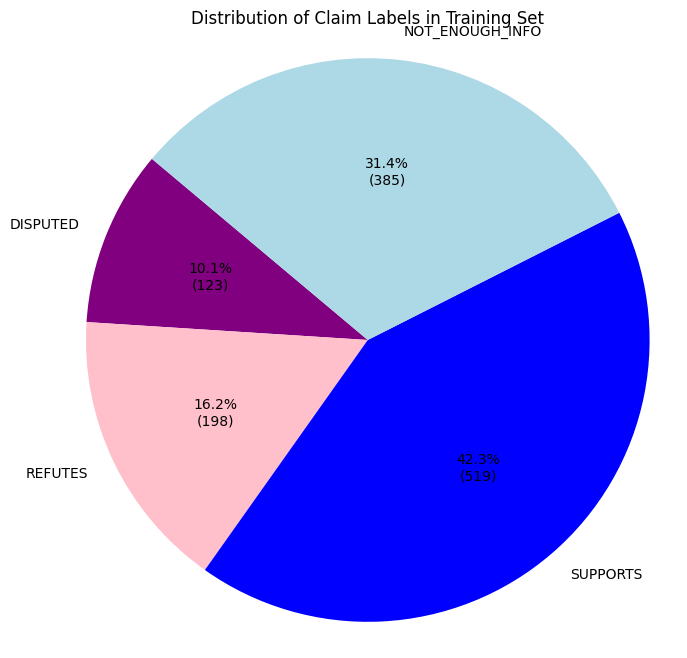

In [4]:
import json
import matplotlib.pyplot as plt
from collections import Counter
from statistics import mean

# Load training data
with open('data/train-claims.json', 'r') as input_file:
    train_claim_data = json.load(input_file)

# Calculate label distribution for training set
label_counts_train = Counter([claim['claim_label'] for claim in train_claim_data.values()])

# Plotting pie chart for training set
labels = list(label_counts_train.keys())
sizes_train = list(label_counts_train.values())
colors_train = ['purple', 'pink', 'blue', 'lightblue']

# Format labels to include both the count and percentage
def format_label(pct, allvals):
    absolute = int(pct / 100. * sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

plt.figure(figsize=(8, 8))
plt.pie(sizes_train, labels=labels, colors=colors_train, autopct=lambda pct: format_label(pct, sizes_train), startangle=140)
plt.axis('equal')
plt.title('Distribution of Claim Labels in Training Set')
plt.show()



In [5]:
train_claim_id = list(train_claim_data.keys())
train_claim_text  = [ v["claim_text"] for v in train_claim_data.values()]
dev_claim_text  = [ v["claim_text"] for v in dev_claim_data.values()]


In [6]:
import json
import nltk
from nltk.corpus import stopwords
import re

nltk.download('punkt')

with open('data/evidence.json', 'r') as input_file:
    evi_data = json.load(input_file)


english_evidence = {}  # Dictionary to store preprocessed English evidence

for evi_id, evi_text in evi_data.items():
    # Check if the text is in English
    words = nltk.word_tokenize(evi_text)
    english_words = [word for word in words if word.isalpha()]
    if len(english_words) / len(words) > 0.5:  # If more than half of the words are English words, consider it as English text
        # If it is in English, perform further preprocessing, such as removing stopwords
        english_text = ' '.join(english_words)
        english_evidence[evi_id] = english_text

# Output the number of filtered evidence
filtered_evidence_count = len(english_evidence)
print("Filtered Evidence Count:", filtered_evidence_count)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\XZH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Filtered Evidence Count: 1181638


In [7]:
import json
import nltk
from nltk.corpus import stopwords
import re

# Extract the most frequently occurring nouns or alphanumeric combinations 
train_claim_text = [claim_value['claim_text'] for claim_value in train_claim_data.values()]
dev_claim_text = [claim_value['claim_text'] for claim_value in dev_claim_data.values()]


stop_words = set(stopwords.words('english'))
# Extract nouns or alphanumeric combinations
claim_words = []
for text_list in [train_claim_text, dev_claim_text]:
    for text in text_list:
        tokens = nltk.word_tokenize(text)
        for token in tokens:
            if re.match('^[a-zA-Z0-9]+$', token) and token.lower() not in stop_words and nltk.pos_tag([token])[0][1] in ['NN', 'NNS', 'NNP', 'NNPS']:
                claim_words.append(token.lower())


top_words_counter = Counter(claim_words)
# Get most frequently occurring words, up to 100 words
top_words = [word for word, _ in top_words_counter.most_common(100)]


print("Top Words:", top_words)


climate_dic = {}

# collect evidence containing the most frequent words into climate_dic
for evi_id, evi_text in english_evidence.items():
    words = nltk.word_tokenize(evi_text)
    if any(word.lower() in top_words for word in words):
        climate_dic[evi_id] = evi_text


# Add all evidence from the training set into climate_dic
for claim_info in train_claim_data.values():
    if "evidences" in claim_info:  
        for evidence_id in claim_info["evidences"]:
            if evidence_id in evi_data:
                evi_text = evi_data[evidence_id]
                climate_dic[evidence_id] = evi_text
            else:
                print("Evidence ID not found:", evidence_id)


print("Number of evidence in climate_dic:", len(climate_dic))

Top Words: ['climate', 'co2', 'ice', 'change', 'temperature', 'sea', 'carbon', 'years', 'temperatures', 'scientists', 'emissions', 'rise', 'earth', 'level', 'dioxide', 'greenhouse', 'record', 'past', 'ocean', 'year', 'levels', 'ipcc', 'century', 'data', 'planet', 'evidence', 'world', 'increase', 'energy', 'trend', 'heat', 'surface', 'effect', 'models', 'water', 'solar', 'human', 'gas', 'humans', 'weather', 'show', 'time', 'degrees', 'warmer', 'cause', 'changes', 'extreme', 'decades', 'found', 'greenland', 'events', 'antarctica', 'today', 'times', 'amount', 'period', 'sun', 'gases', 'polar', 'percent', 'study', 'cent', 'satellite', 'measurements', 'report', 'research', 'impact', 'oceans', 'half', 'united', 'rate', 'shows', 'states', 'cold', 'science', 'activity', 'fact', 'air', 'mean', 'summer', 'studies', 'warm', 'fossil', 'cycle', 'glaciers', 'stations', 'increases', 'age', 'australia', 'el', 'land', 'means', 'forests', 'term', 'trends', 'decline', 'celsius', 'scientist', 'power', 'li

In [9]:

train_dev_evidence_ids = set()
for claim_data in [train_claim_data, dev_claim_data]:
    for claim_info in claim_data.values():
        if "evidences" in claim_info:  
            train_dev_evidence_ids.update(claim_info["evidences"])

# Check if the evidence in the training set and development set appears in climate_dic
missing_evidence_ids = [evi_id for evi_id in train_dev_evidence_ids if evi_id not in climate_dic]


print("Number of evidence not in climate_dic:", len(missing_evidence_ids))


Number of evidence not in climate_dic: 55


In [10]:
# Calculate the total number of evidence IDs in the test set and development set
total_evidence_ids = set()

for claim_data in [train_claim_data, dev_claim_data]:
    for claim_info in claim_data.values():
        if "evidences" in claim_info:  
            total_evidence_ids.update(claim_info["evidences"])


print("Total number of evidence IDs:", len(total_evidence_ids))


Total number of evidence IDs: 3443


In [11]:
import json

output_file_path = "climate_dic.json"


with open(output_file_path, 'w') as output_file:
    json.dump(climate_dic, output_file)

print("Climate dictionary saved to", output_file_path)


Climate dictionary saved to climate_dic.json
